# Turbid-water backscattering models in BING

`Pow2` and `Pow2Flat` split particulate backscattering into a **mineral**
term (near-flat, pivoted at 700 nm) and an **organic** term (steeper,
pivoted at 600 nm):

$$b_{bp}(\lambda) = 10^{B_{min}}\left(\frac{700}{\lambda}\right)^{\eta_{min}}
+ 10^{B_{org}}\left(\frac{600}{\lambda}\right)^{\eta_{org}}$$

`Pow2Flat` is the same with $\eta_{min}\equiv 0$ (a constant mineral term),
giving 3 parameters instead of 4.

**Why.** Fits of turbid GLORIA spectra fail because a *single decreasing*
power law cannot supply the backscatter the red needs: the required
$b_b$ rises to ~0.2-0.4 m$^{-1}$ while a fitted single power law sits flat
near 0.013 m$^{-1}$. Measurements agree that mineral-dominated water has
larger, flatter backscatter (Snyder et al. 2008, doi:10.1364/AO.47.000666;
Doxaran et al. 2009, doi:10.4319/lo.2009.54.4.1257; Neukermans et al. 2012,
doi:10.4319/lo.2012.57.1.0124). Full investigation:
`IOPtics/reports/gloria_fits_report.md`.

This notebook covers three things:
1. what the new shapes look like,
2. a controlled experiment showing **two components are necessary** (and
   that widening the single power law's slope range is *not* enough),
3. a no-regression check on a clear open-ocean L23 spectrum.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt

from bing.models import bbnw as bing_bbnw
from bing.models import utils as model_utils
from bing.parameters import standard
from bing.fitting import chisq_fit
from bing.rt import defs as rt_defs

wave = np.arange(400., 755., 5.)

# Colourblind-safe qualitative colours
CLR = {'Pow': '#0072B2', 'PowFlex': '#E69F00',
       'Pow2': '#009E73', 'Pow2Flat': '#CC79A7', 'truth': 'k'}
print('bb models registered:',
      [n for n in ['Cst', 'Pow', 'Lee', 'GSM', 'Every', 'Pow2', 'Pow2Flat']])

bb models registered: ['Cst', 'Pow', 'Lee', 'GSM', 'Every', 'Pow2', 'Pow2Flat']


## 1. The shapes

The open-ocean `Pow` prior floors `beta` at 0, so `bb_nw` can only
*decrease* with wavelength. `PowFlex` widens that prior to allow a flat or
rising slope; `Pow2` instead adds a second component, which lets the red
be lifted **without** flattening the blue.

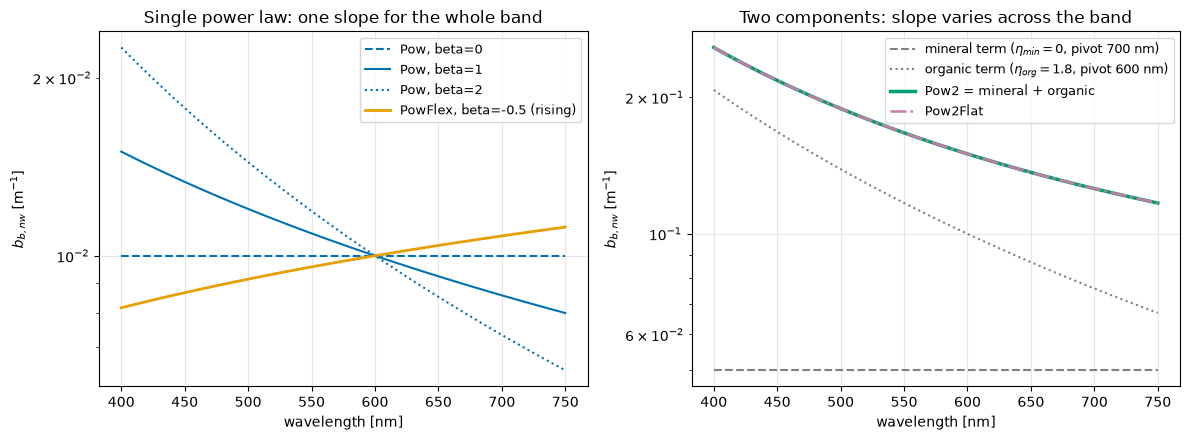

In [2]:
pow_m = bing_bbnw.init_model('Pow', wave)
pow2_m = bing_bbnw.init_model('Pow2', wave)
flat_m = bing_bbnw.init_model('Pow2Flat', wave)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

# -- left: what a single power law can do
ax = axs[0]
for beta, ls in [(0., '--'), (1., '-'), (2., ':')]:
    ax.plot(wave, pow_m.eval_bbnw(np.array([-2., beta]))[0],
            color=CLR['Pow'], ls=ls, label=f'Pow, beta={beta:.0f}')
ax.plot(wave, pow_m.eval_bbnw(np.array([-2., -0.5]))[0],
        color=CLR['PowFlex'], lw=2,
        label='PowFlex, beta=-0.5 (rising)')
ax.set_title('Single power law: one slope for the whole band')
ax.legend(fontsize=9)

# -- right: two components, shown decomposed
ax = axs[1]
par = np.array([np.log10(0.05), 0.0, np.log10(0.10), 1.8])
mineral = 10**par[0]*(pow2_m.pivot_min/wave)**par[1]
organic = 10**par[2]*(pow2_m.pivot/wave)**par[3]
ax.plot(wave, mineral, color='0.5', ls='--',
        label=r'mineral term ($\eta_{min}=0$, pivot 700 nm)')
ax.plot(wave, organic, color='0.5', ls=':',
        label=r'organic term ($\eta_{org}=1.8$, pivot 600 nm)')
ax.plot(wave, pow2_m.eval_bbnw(par)[0], color=CLR['Pow2'], lw=2.5,
        label='Pow2 = mineral + organic')
ax.plot(wave, flat_m.eval_bbnw(np.array([par[0], par[2], par[3]]))[0],
        color=CLR['Pow2Flat'], ls='-.', lw=1.8, label='Pow2Flat')
ax.set_title('Two components: slope varies across the band')
ax.legend(fontsize=9)

for ax in axs:
    ax.set_yscale('log')
    ax.set_xlabel('wavelength [nm]')
    ax.set_ylabel(r'$b_{b,nw}$ [m$^{-1}$]')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### The key point, numerically

For a two-component `bb_nw`, the **local log-log slope changes with
wavelength**. A single power law has one slope by construction, which is
why no choice of `beta` can match it.

In [3]:
bb2 = pow2_m.eval_bbnw(par)[0]
lslope = -np.gradient(np.log10(bb2), np.log10(wave))
for wv in (420., 550., 700.):
    i = int(np.argmin(np.abs(wave - wv)))
    print(f'  local slope at {wv:.0f} nm: {lslope[i]:+.2f}')
print('\nA single power law must use ONE of these everywhere.')

  local slope at 420 nm: +1.43
  local slope at 550 nm: +1.26
  local slope at 700 nm: +1.08

A single power law must use ONE of these everywhere.


## 2. Two components are necessary (controlled experiment)

Build a synthetic Rrs from a *known* two-component `bb_nw` (organic
dominating the blue, mineral the red), then fit it four ways. This is the
"form, not range" test: if the problem were merely the *range* of the
slope prior, `PowFlex` would fix it.

In [4]:
wv_fit = np.arange(400., 705., 5.)

def fit_setup(p):
    models = model_utils.init(p.model_names, wv_fit, (p.apriors, p.bpriors))
    models[0].set_aph(np.array([2.0]))     # Bricaud aph needs a Chl
    rt = rt_defs.rt_dict_from_p(p)
    lo = np.array([d['pmin'] for d in p.apriors] +
                  [d['pmin'] for d in p.bpriors], float)
    hi = np.array([d['pmax'] for d in p.apriors] +
                  [d['pmax'] for d in p.bpriors], float)
    return models, rt, (lo, hi)

# Truth: Adg, Sdg, Aph, then Bmin, eta_min, Borg, eta_org
truth = np.array([-0.3, 0.015, -0.4, np.log10(0.05), 0.0,
                  np.log10(0.10), 1.8])
p_true = standard.expb_pow2(wv_min=400., wv_max=700.,
                            variable_Gordon=False)
m_true, rt_true, _ = fit_setup(p_true)
Rrs = chisq_fit.fit_func(wv_fit, *truth, models=m_true, rt_dict=rt_true)
varRrs = (0.02*Rrs)**2
bb_truth = m_true[1].eval_bbnw(truth[3:])[0]

CASES = [('Pow', 'expb_pow', np.array([-.5, .015, -.5, -1., .5])),
         ('PowFlex', 'expb_powflex', np.array([-.5, .015, -.5, -1., .5])),
         ('Pow2Flat', 'expb_pow2flat',
          np.array([-.5, .015, -.5, -1., -2., 1.])),
         ('Pow2', 'expb_pow2',
          np.array([-.5, .015, -.5, -1., .05, -2., 1.]))]

results = {}
for label, combo, p0 in CASES:
    p = getattr(standard, combo)(wv_min=400., wv_max=700.,
                                 variable_Gordon=False)
    models, rt, bnds = fit_setup(p)
    ans, _, _ = chisq_fit.fit((Rrs, varRrs, p0, 0), models, rt, bounds=bnds)
    pred = chisq_fit.fit_func(wv_fit, *ans, models=models, rt_dict=rt)
    results[label] = dict(ans=ans, pred=pred, models=models,
                          bb=models[1].eval_bbnw(ans[3:])[0])

print(f'{"model":10s} {"n bb par":>9s} {"median |dRrs|/Rrs":>19s}'
      f' {"max":>10s}')
for label, _, _ in CASES:
    r = results[label]
    rel = np.abs(r['pred'] - Rrs)/Rrs
    print(f'{label:10s} {r["ans"].size - 3:9d} '
          f'{np.median(rel):19.2e} {np.max(rel):10.2e}')

model       n bb par   median |dRrs|/Rrs        max
Pow                2            7.40e-04   5.05e-03
PowFlex            2            7.40e-04   5.05e-03
Pow2Flat           3            8.21e-16   1.52e-15
Pow2               4            2.11e-16   5.96e-16


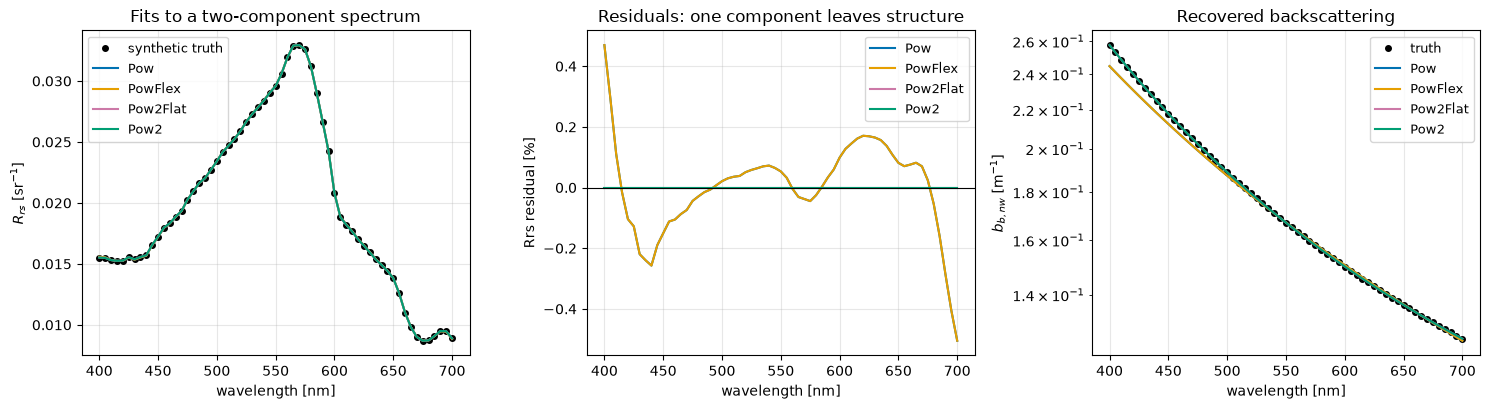

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axs[0]
ax.plot(wv_fit, Rrs, 'o', ms=4, color=CLR['truth'], label='synthetic truth')
for label, _, _ in CASES:
    ax.plot(wv_fit, results[label]['pred'], color=CLR[label], label=label)
ax.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax.set_title('Fits to a two-component spectrum')

ax = axs[1]
for label, _, _ in CASES:
    ax.plot(wv_fit, 100*(results[label]['pred'] - Rrs)/Rrs,
            color=CLR[label], label=label)
ax.axhline(0., color='k', lw=0.8)
ax.set_ylabel('Rrs residual [%]')
ax.set_title('Residuals: one component leaves structure')

ax = axs[2]
ax.plot(wv_fit, bb_truth, 'o', ms=4, color=CLR['truth'], label='truth')
for label, _, _ in CASES:
    ax.plot(wv_fit, results[label]['bb'], color=CLR[label], label=label)
ax.set_yscale('log')
ax.set_ylabel(r'$b_{b,nw}$ [m$^{-1}$]')
ax.set_title('Recovered backscattering')

for ax in axs:
    ax.set_xlabel('wavelength [nm]')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# The decisive detail: PowFlex lands on the SAME optimum as Pow, with a
# positive slope -- i.e. inside expb_pow's existing prior range.
print('Pow      fitted bb params:', np.round(results['Pow']['ans'][3:], 4))
print('PowFlex  fitted bb params:', np.round(results['PowFlex']['ans'][3:], 4))
print('identical:', np.allclose(results['Pow']['ans'],
                                results['PowFlex']['ans'], atol=1e-3))
print()
print('Pow2     fitted bb params:', np.round(results['Pow2']['ans'][3:], 4))
print('         truth           :', np.round(truth[3:], 4))
print()
print('=> Widening the slope RANGE buys nothing; adding a second')
print('   component recovers the truth exactly.')

Pow      fitted bb params: [-0.8224  1.1973]
PowFlex  fitted bb params: [-0.8224  1.1973]
identical: True

Pow2     fitted bb params: [-1.301  0.    -1.     1.8  ]
         truth           : [-1.301  0.    -1.     1.8  ]

=> Widening the slope RANGE buys nothing; adding a second
   component recovers the truth exactly.


## 3. No regression on clear open-ocean water (L23)

A 4-parameter backscattering model must not buy turbid performance at the
cost of the clear-water case. Fit one clear L23 spectrum (idx 170, Rrs
peaking at 400 nm) with each model through the standard L23 machinery.

Raw chi-squared should be **identical** -- `Pow2` contains `Pow` exactly
(kill the mineral term and the pivots agree), so on a spectrum that a
single power law already fits, it should simply reproduce that solution.
The reduced chi-squared rises by exactly the degrees-of-freedom
bookkeeping, nothing more.

In [7]:
from bing.fitting import l23 as fit_l23

L23_IDX = 170
l23_res = {}
for label, combo in [('Pow', 'expb_pow'), ('PowFlex', 'expb_powflex'),
                     ('Pow2Flat', 'expb_pow2flat'), ('Pow2', 'expb_pow2')]:
    p = getattr(standard, combo)(satellite='PACE', add_noise=False,
                                 variable_Gordon=True)
    ans, _, models, prep, _ = fit_l23.fit_with_LM(p, L23_IDX)
    rt = rt_defs.rt_dict_from_p(p)
    pred = chisq_fit.fit_func(models[0].wave, *ans, models=models,
                              rt_dict=rt)
    Rrs_l23, var_l23 = prep['model_Rrs'], prep['model_varRrs']
    chi2 = float(np.sum((pred - Rrs_l23)**2/var_l23))
    l23_res[label] = dict(ans=ans, pred=pred, models=models, prep=prep,
                          chi2=chi2, k=ans.size,
                          chi2nu=chi2/(Rrs_l23.size - ans.size),
                          bb=models[1].eval_bbnw(ans[3:])[0])

print(f'{"model":10s} {"k":>3s} {"chi2":>10s} {"chi2_nu":>10s}')
for label in ('Pow', 'PowFlex', 'Pow2Flat', 'Pow2'):
    r = l23_res[label]
    print(f'{label:10s} {r["k"]:3d} {r["chi2"]:10.4f} {r["chi2nu"]:10.5f}')

model        k       chi2    chi2_nu
Pow          5     0.1357    0.00242
PowFlex      5     0.1357    0.00242
Pow2Flat     6     0.1357    0.00247
Pow2         7     0.1357    0.00251


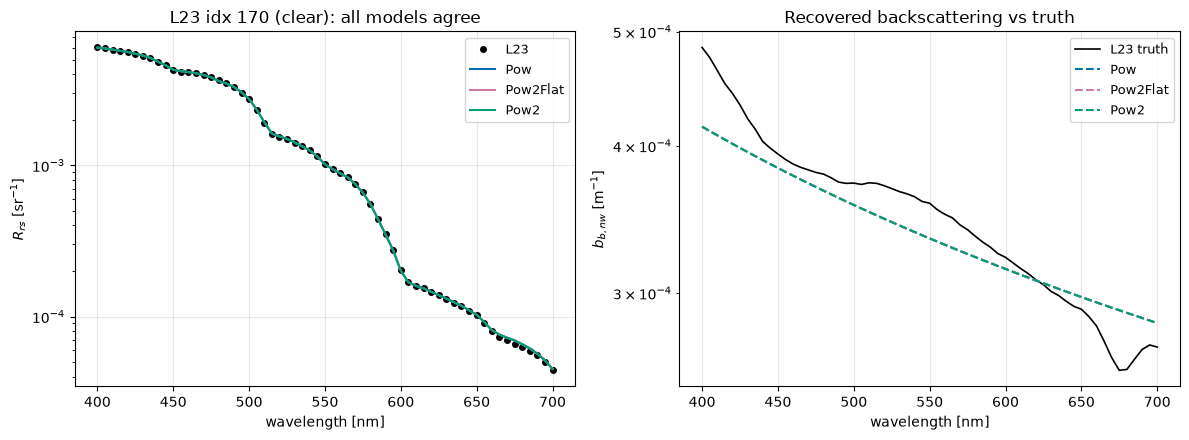

In [8]:
ref = l23_res['Pow']
wave_l23 = ref['models'][0].wave
Rrs_l23 = ref['prep']['model_Rrs']
bbnw_true = ref['prep']['odict']['bbnw']        # L23 truth
wave_true = ref['prep']['odict']['true_wave']

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axs[0]
ax.plot(wave_l23, Rrs_l23, 'o', ms=4, color=CLR['truth'], label='L23')
for label in ('Pow', 'Pow2Flat', 'Pow2'):
    ax.plot(wave_l23, l23_res[label]['pred'], color=CLR[label], label=label)
ax.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax.set_yscale('log')
ax.set_title(f'L23 idx {L23_IDX} (clear): all models agree')

ax = axs[1]
ax.plot(wave_true, bbnw_true, 'k-', lw=1.2, label='L23 truth')
for label in ('Pow', 'Pow2Flat', 'Pow2'):
    ax.plot(wave_l23, l23_res[label]['bb'], color=CLR[label], ls='--',
            label=label)
ax.set_yscale('log')
ax.set_ylabel(r'$b_{b,nw}$ [m$^{-1}$]')
ax.set_title('Recovered backscattering vs truth')

for ax in axs:
    ax.set_xlabel('wavelength [nm]')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| | clear L23 (idx 170) | two-component synthetic |
|---|---|---|
| `Pow` | fits (chi2 = 0.136) | plateaus at ~1e-3 median misfit |
| `PowFlex` | identical to `Pow` | **identical to `Pow`** -- range is not the problem |
| `Pow2Flat` | same raw chi2 | recovers exactly |
| `Pow2` | same raw chi2 | recovers exactly (all 4 params) |

So the two-component models are a strict generalisation: they cost nothing
on open-ocean water and are the only ones that can represent a
backscattering spectrum whose slope changes across the band.

**Next:** benchmark on real turbid GLORIA spectra and settle
identifiability (MCMC vs an inflated noise floor vs fixing
$\eta_{min}$ via `Pow2Flat`).